In [1]:


# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

import geopandas as gpd
import torch
from torch.utils.data import Dataset,DataLoader,random_split
import torch.nn as nn
import torch.optim as optim
import torchvision




In [2]:
df = pd.read_csv("D:\\sarah_venv\\disasterrisk\\natural_disasters_2024.csv") 
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Disaster_ID,Disaster_Type,Location,Magnitude,Date,Fatalities,Economic_Loss($)
0,1,Wildfire,Brazil,6.267393,2024-01-01 00:00:00,9706,6.509790e+08
1,2,Hurricane,Indonesia,6.649358,2024-01-01 01:00:00,2233,5.538357e+08
2,3,Tornado,China,9.724366,2024-01-01 02:00:00,478,6.910998e+07
3,4,Flood,India,1.702505,2024-01-01 03:00:00,2867,8.474880e+08
4,5,Flood,Brazil,7.917748,2024-01-01 04:00:00,776,6.449297e+08


In [3]:
le_type = LabelEncoder()
df['Disaster_Type_Encoded'] = le_type.fit_transform(df['Disaster_Type'])

le_loc = LabelEncoder()
df['Location_Encoded'] = le_loc.fit_transform(df['Location'])

In [4]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [5]:
df.fillna(0, inplace=True)

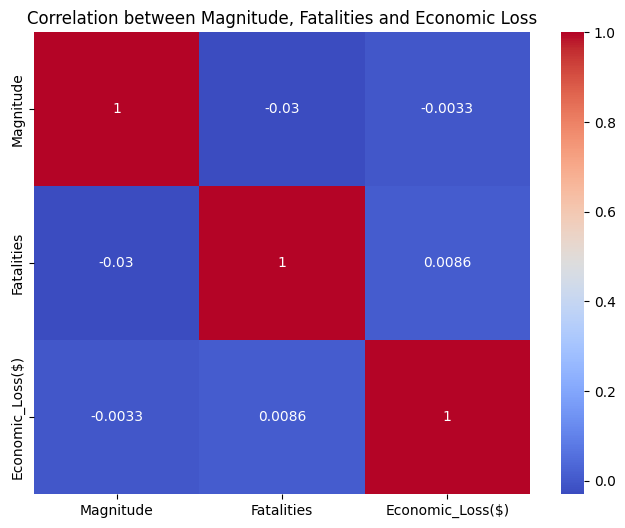

In [6]:


plt.figure(figsize=(8,6))
sns.heatmap(df[['Magnitude','Fatalities','Economic_Loss($)']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Magnitude, Fatalities and Economic Loss")
plt.show()

In [7]:
disaster_freq = df.groupby('Location')['Disaster_ID'].count().reset_index().rename(columns={'Disaster_ID':'Disaster_Freq'})
df = df.merge(disaster_freq, on='Location', how='left')

In [7]:
scaler = MinMaxScaler()
df['Fatalities_Scaled'] = scaler.fit_transform(df[['Fatalities']])
df['Economic_Loss_Scaled'] = scaler.fit_transform(df[['Economic_Loss($)']])

# Severity Score = Magnitude * (Scaled Fatalities + Scaled Economic Loss)
df['Severity_Score'] = df['Magnitude'] * (df['Fatalities_Scaled'] + df['Economic_Loss_Scaled'])


In [9]:
vuln_df = df.groupby('Location').agg({
    'Fatalities_Scaled':'mean',
    'Economic_Loss_Scaled':'mean',
    'Disaster_Freq':'mean',
    'Severity_Score':'mean'
}).reset_index()

vuln_df['Vulnerability_Score'] = (
    0.3*vuln_df['Fatalities_Scaled'] +
    0.3*vuln_df['Economic_Loss_Scaled'] +
    0.2*(vuln_df['Disaster_Freq']/vuln_df['Disaster_Freq'].max()) +
    0.2*(vuln_df['Severity_Score']/vuln_df['Severity_Score'].max())
)

top_vuln = vuln_df.sort_values('Vulnerability_Score', ascending=False).head(10)
print(top_vuln[['Location','Vulnerability_Score']])

    Location  Vulnerability_Score
0     Brazil             0.700918
5        USA             0.692895
4      Japan             0.684585
2      India             0.684270
3  Indonesia             0.683653
1      China             0.680451


In [10]:
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = iso_forest.fit_predict(df[['Magnitude','Fatalities','Economic_Loss($)']])
anomalies = df[df['Anomaly']==-1]
print(f"Detected {len(anomalies)} anomalous events")
print(anomalies[['Disaster_Type','Location','Magnitude','Fatalities','Economic_Loss($)']])


Detected 500 anomalous events
     Disaster_Type   Location  Magnitude  Fatalities  Economic_Loss($)
2          Tornado      China   9.724366         478      6.910998e+07
9            Flood      India   1.024187        5135      9.985833e+08
19      Earthquake      Japan   9.546151         142      4.703654e+08
30       Hurricane  Indonesia   9.709791          59      9.208219e+07
43       Hurricane     Brazil   1.150600        9842      9.294212e+08
...            ...        ...        ...         ...               ...
9865     Hurricane     Brazil   7.194964        9983      9.964897e+08
9931    Earthquake        USA   5.867431         464      1.002566e+07
9934      Wildfire      China   2.171249         105      9.258194e+08
9970     Hurricane  Indonesia   7.585380         194      4.006204e+07
9988       Tornado      Japan   9.213056        9599      2.543005e+06

[500 rows x 5 columns]


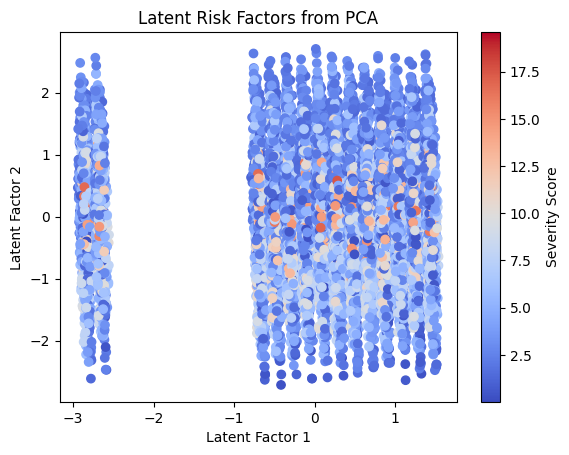

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use numeric features
features = ['Magnitude', 'Fatalities', 'Economic_Loss($)', 'Disaster_Freq', 'Year', 'Month']
X_num = df[features]

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# PCA to extract 2 latent factors
pca = PCA(n_components=2)
latent_factors = pca.fit_transform(X_scaled)

# Add to dataframe
df['Latent_Factor1'] = latent_factors[:,0]
df['Latent_Factor2'] = latent_factors[:,1]

# Plot
plt.scatter(df['Latent_Factor1'], df['Latent_Factor2'], c=df['Severity_Score'], cmap='coolwarm')
plt.colorbar(label='Severity Score')
plt.xlabel('Latent Factor 1')
plt.ylabel('Latent Factor 2')
plt.title('Latent Risk Factors from PCA')
plt.show()


In [29]:
import pandas as pd

# Filter only earthquake events (case-insensitive)
earthquake_df = df[df['Disaster_Type'].str.contains("Earthquake", case=False)]

# Count number of earthquakes per country
earthquake_counts = earthquake_df.groupby('Location').size().reset_index(name='Earthquake_Count')

# Sort descending to see top countries
earthquake_counts = earthquake_counts.sort_values(by='Earthquake_Count', ascending=False)
print(earthquake_counts.head(10))



    Location  Earthquake_Count
0     Brazil               362
4      Japan               343
1      China               341
3  Indonesia               336
2      India               334
5        USA               320


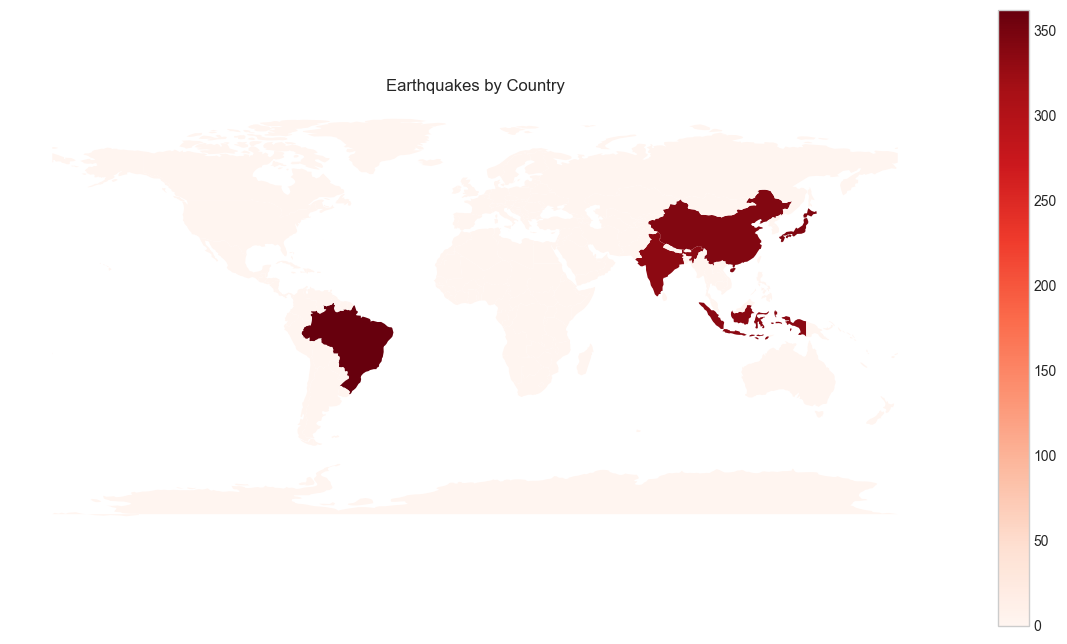

In [48]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Load online GeoJSON
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url)

# Merge earthquake counts
earthquake_df = df[df['Disaster_Type'].str.contains("Earthquake", case=False)]
counts = earthquake_df.groupby('Location').size().reset_index(name='Earthquake_Count')
world = world.merge(counts, left_on='name', right_on='Location', how='left')
world['Earthquake_Count'] = world['Earthquake_Count'].fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(15,8))
world.plot(column='Earthquake_Count', cmap='Reds', legend=True, ax=ax)
ax.set_title("Earthquakes by Country")
ax.axis('off')
plt.show()


In [37]:
# Severity score (customizable)
df['Severity'] = (
    0.5 * df['Fatalities'] +
    0.3 * df['Economic_Loss($)'] +
    0.2 * df['Magnitude']
)

df['Severity'] = df['Severity'] / df['Severity'].max()  # normalize


In [1]:
import pygad
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [11]:
X = X.select_dtypes(exclude=["datetime64"])

y = df["Disaster_Type"]

# Encode categorical input columns
X = pd.get_dummies(X)

# Encode target labels to integers
le = LabelEncoder()
y = le.fit_transform(y)

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
def fitness_func(ga_instance, solution, sol_idx):
    n_estimators = int(solution[0])
    max_depth = int(solution[1])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    # Accuracy as fitness
    return accuracy_score(y_val, y_pred)


In [16]:
# PyGAD settings
ga_instance = pygad.GA(
    num_generations=5,          # ↓ from 20
    sol_per_pop=6,              # ↓ from 10
    num_parents_mating=3,
    fitness_func=fitness_func,
    num_genes=2,
    gene_space=[range(50, 150), range(3, 15)],
    mutation_percent_genes=10
)


# Run GA
ga_instance.run()

# Get best solution
best_solution, best_solution_fitness, _ = ga_instance.best_solution()
print("Best Hyperparameters:", best_solution)
print("Best Fitness (accuracy):", best_solution_fitness)

print("n_estimators:", int(best_solution[0]))
print("max_depth:", int(best_solution[1]))


d:\sarah_venv\sarah_venv\Lib\site-packages\pygad\pygad.py:753: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate (mutation_percent_genes={mutation_percent_genes}) resulted in selecting ({mutation_num_genes}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


Best Hyperparameters: [69.  8.]
Best Fitness (accuracy): 1.0
n_estimators: 69
max_depth: 8


In [7]:
from sklearn.preprocessing import StandardScaler
X = df[['Disaster_ID','Magnitude']].values
y = df['Disaster_ID'].values.reshape(-1, 1)  # ensure it's 2D for regression

# Optional: Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [10]:
import torch.nn as nn

input_dim = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)  # output 1 for regression
)

In [11]:
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
num_epochs = 50

for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/50], Loss: 33460632.0000
Epoch [20/50], Loss: 33455648.0000
Epoch [30/50], Loss: 33449722.0000
Epoch [40/50], Loss: 33442470.0000
Epoch [50/50], Loss: 33433288.0000


In [13]:
with torch.no_grad():
    y_pred = model(X_test)
    test_loss = criterion(y_pred, y_test)
    print(f'Test Loss: {test_loss.item():.4f}')

Test Loss: 32810806.0000
